In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
# ==========================================
# 0. preparing
# ==========================================
CONFIG = {
    'file_path': 'Adidas_US_Sales_Dataset.csv',
    'date_col': 'invoicedate',
    'target_col': 'totalsales',
    'look_back': 60,
    'batch_size': 16,
    'epochs': 150,
    'learning_rate': 0.0005,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print(f"using: {CONFIG['device']}")

using: cpu


In [27]:
# ==========================================
# 1. Data Cleaning
# ==========================================
def load_and_clean_data(config):
    # A. Read data
    try:
        df = pd.read_csv(config['file_path'], sep=None, engine='python')
    except Exception as e:
        print(f"fail: {e}")
        df = pd.read_csv(config['file_path'])  # Fallback

    # B. Column name standardisation (removing any spaces present in column names)
    df.columns = df.columns.str.lower().str.replace(' ', '')

    # Verify whether the listed entry exists
    if config['date_col'] not in df.columns or config['target_col'] not in df.columns:
        raise ValueError(f"List mismatch!: {df.columns.tolist()}")

    # C. Cleaning the 'totalsales' column (crucial step!)
    # The raw data may be in the format "$12 345", requiring the removal of the '$' and ' '.
    if df[config['target_col']].dtype == 'object':
        df[config['target_col']] = df[config['target_col']].astype(str).str.replace(r'[$\s,]', '', regex=True)
        df[config['target_col']] = pd.to_numeric(df[config['target_col']])

    # D. Date of analysis
    df[config['date_col']] = pd.to_datetime(df[config['date_col']], format='%d/%m/%Y', errors='coerce')
    if df[config['date_col']].isnull().all():
        df[config['date_col']] = pd.to_datetime(df[config['date_col']])

    # E. Aggregation
    # The raw data is "per order", and we need to forecast "total daily sales".
    daily_df = df.groupby(config['date_col'])[config['target_col']].sum().reset_index()

    # F. Resampling
    # Sales data frequently exhibits gaps and must be completed to form a continuous time series.
    daily_df = daily_df.set_index(config['date_col'])
    daily_df = daily_df.resample('D').sum().fillna(0)
    daily_df = daily_df.reset_index()

    return daily_df

In [28]:
# Execute cleaning and loading
df_clean = load_and_clean_data(CONFIG)
print("Data Preview (First 5 Rows):")
print(df_clean.head())
print(f"Total number of days: {len(df_clean)}")

Data Preview (First 5 Rows):
  invoicedate  totalsales
0  2020-01-01      845141
1  2020-01-02      689410
2  2020-01-03      632573
3  2020-01-04      615080
4  2020-01-05      707829
Total number of days: 731


In [29]:
# ==========================================
# 2. Feature Engineering
# ==========================================
def process_features(df, config):
    data = df.copy()
    target = config['target_col']

    # A. Smoothing (EWMA) - Reduces noise while preserving trends
    smooth_col = f"{target}_smooth"
    data[smooth_col] = data[target].ewm(span=7, adjust=False).mean()

    # B. Lag Features
    data['lag_1'] = data[smooth_col].shift(1)
    data['lag_7'] = data[smooth_col].shift(7)

    # C. Time Embeddings
    # Map the months and days of the week onto the circular ring (sin/cos)
    date_series = data[config['date_col']]
    data['month_sin'] = np.sin(2 * np.pi * date_series.dt.month / 12)
    data['month_cos'] = np.cos(2 * np.pi * date_series.dt.month / 12)
    data['day_sin'] = np.sin(2 * np.pi * date_series.dt.dayofweek / 7)
    data['day_cos'] = np.cos(2 * np.pi * date_series.dt.dayofweek / 7)

    data.dropna(inplace=True)

    # Define the feature columns for final use
    feature_cols = [smooth_col, 'lag_1', 'lag_7', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

    return data, feature_cols


In [30]:
df_processed, feature_cols = process_features(df_clean, CONFIG)

In [31]:
# ==========================================
# 3. Sliding Window
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))
data_values = df_processed[feature_cols].values
data_scaled = scaler.fit_transform(data_values)


def create_dataset(dataset, look_back):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i: i + look_back])
        Y.append(dataset[i + look_back, 0])  # Sales figures after smoothing
    return np.array(X), np.array(Y)


X, y = create_dataset(data_scaled, CONFIG['look_back'])

# Partitioning the training set (85%) and test set (15%)
train_size = int(len(X) * 0.85)
X_train = torch.FloatTensor(X[:train_size]).to(CONFIG['device'])
y_train = torch.FloatTensor(y[:train_size]).unsqueeze(1).to(CONFIG['device'])
X_test = torch.FloatTensor(X[train_size:]).to(CONFIG['device'])
y_test = torch.FloatTensor(y[train_size:]).unsqueeze(1).to(CONFIG['device'])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=CONFIG['batch_size'], shuffle=True)

In [32]:
# ==========================================
# 4. Model Definition: Hybrid Convolutional Neural Network with Residual Connections
# ==========================================
class MultiScaleCNN_Res(nn.Module):
    def __init__(self, num_features, sequence_length):
        super(MultiScaleCNN_Res, self).__init__()

        # --- branch 1: Weekly---
        self.branch1 = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten()
        )

        # --- branch 2: Monthly ---
        self.branch2 = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten()
        )

        # --- branch 3: Quarterly ---
        self.branch3 = nn.Sequential(
            nn.Conv1d(num_features, 32, kernel_size=45, padding=22),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten()
        )

        # --- Fusion Layer (Predicted Change Delta) ---
        self.regressor = nn.Sequential(
            nn.Linear(160, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x shape: [Batch, Length, Features]

        # [Key Steps] Extract Anchor Points: Yesterday's Smoothed Sales Figures
        # target_smooth
        last_val = x[:, -1, 0].unsqueeze(1)

        # Permute for Conv1d
        x_in = x.permute(0, 2, 1)

        out1 = self.branch1(x_in)
        out2 = self.branch2(x_in)
        out3 = self.branch3(x_in)

        combined = torch.cat((out1, out2, out3), dim=1)

        delta = self.regressor(combined)

        return last_val + delta

In [33]:
model = MultiScaleCNN_Res(num_features=X_train.shape[2], sequence_length=CONFIG['look_back']).to(CONFIG['device'])
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)

In [34]:
# ==========================================
# 5. Training cycle
# ==========================================
print("Commencing training...")
history_loss = []

for epoch in range(CONFIG['epochs']):
    model.train()
    batch_losses = []

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    avg_loss = np.mean(batch_losses)
    history_loss.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{CONFIG['epochs']} | Loss: {avg_loss:.6f}")

Commencing training...
Epoch 10/150 | Loss: 0.003916
Epoch 20/150 | Loss: 0.003462
Epoch 30/150 | Loss: 0.002984
Epoch 40/150 | Loss: 0.002264
Epoch 50/150 | Loss: 0.001739
Epoch 60/150 | Loss: 0.001701
Epoch 70/150 | Loss: 0.001770
Epoch 80/150 | Loss: 0.001344
Epoch 90/150 | Loss: 0.001455
Epoch 100/150 | Loss: 0.001489
Epoch 110/150 | Loss: 0.001172
Epoch 120/150 | Loss: 0.001291
Epoch 130/150 | Loss: 0.001049
Epoch 140/150 | Loss: 0.001318
Epoch 150/150 | Loss: 0.001179


In [35]:
# ==========================================
# 6. Forecasting and Evaluation
# ==========================================
model.eval()
with torch.no_grad():
    train_pred = model(X_train).cpu().numpy()
    test_pred = model(X_test).cpu().numpy()


# de-normalisation
def inverse_transform(pred_array, scaler):
    dummy = np.zeros((len(pred_array), len(feature_cols)))
    dummy[:, 0] = pred_array.flatten()
    return scaler.inverse_transform(dummy)[:, 0]


y_test_real = inverse_transform(y_test.cpu().numpy(), scaler)
test_pred_real = inverse_transform(test_pred, scaler)

rmse = np.sqrt(mean_squared_error(y_test_real, test_pred_real))
mae = mean_absolute_error(y_test_real, test_pred_real)
r2 = r2_score(y_test_real,  test_pred_real)
print(f"\n[Test set results] RMSE: {rmse:.2f}, MAE: {mae:.2f}, R² Score: {r2:.4f}")


[Test set results] RMSE: 456616.50, MAE: 306275.26, R² Score: 0.7282


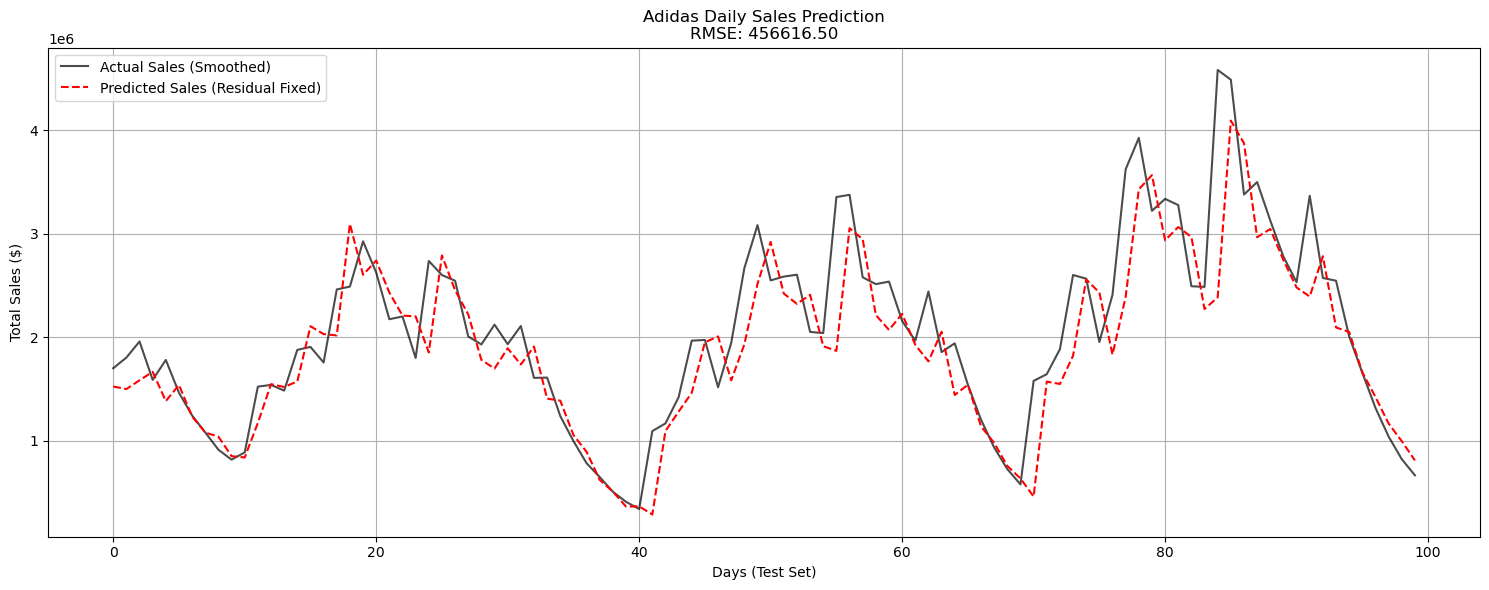

In [36]:
# ==========================================
# 7. Visualisation
# ==========================================
plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Actual Sales (Smoothed)', color='black', alpha=0.7)
plt.plot(test_pred_real, label='Predicted Sales (Residual Fixed)', color='red', linestyle='--', linewidth=1.5)

plt.title(f'Adidas Daily Sales Prediction\nRMSE: {rmse:.2f}')
plt.xlabel('Days (Test Set)')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()